In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pickle

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

import warnings
warnings.filterwarnings('ignore')

device = torch.device('cpu' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

Usando dispositivo: cpu


## 1. Carga de Datos

In [2]:
X_train_scaled = np.load('../data/processed/X_train_scaled.npy')
X_test_scaled = np.load('../data/processed/X_test_scaled.npy')
y_train = np.load('../data/processed/y_train.npy')
y_test = np.load('../data/processed/y_test.npy')

X_train_eng_scaled = np.load('../data/processed/X_train_eng_scaled.npy')
X_test_eng_scaled = np.load('../data/processed/X_test_eng_scaled.npy')

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_train_eng_scaled shape: {X_train_eng_scaled.shape}")

X_train_scaled shape: (67229, 31)
X_train_eng_scaled shape: (67229, 56)


## 2. Definición del Autoencoder

In [3]:
class Autoencoder(nn.Module):
    """
    Autoencoder simple para reducción no-lineal de dimensionalidad.
    """
    def __init__(self, input_size, latent_size):
        super(Autoencoder, self).__init__()
        
        hidden_size = (input_size + latent_size) // 2
        
        self.encoder = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_size),
            nn.Linear(hidden_size, latent_size),
            nn.ReLU()
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_size, hidden_size),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_size),
            nn.Linear(hidden_size, input_size)
        )
    
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded
    
    def encode(self, x):
        return self.encoder(x)

print("Arquitectura de Autoencoder definida.")

Arquitectura de Autoencoder definida.


## 3. Preparación de DataLoaders

In [4]:
X_train_tensor = torch.FloatTensor(X_train_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)

train_dataset = TensorDataset(X_train_tensor)
test_dataset = TensorDataset(X_test_tensor)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("DataLoaders creados.")

DataLoaders creados.


## 4. Función de Entrenamiento del Autoencoder

In [5]:
def train_autoencoder(model, train_loader, test_loader, criterion, optimizer, num_epochs=100, device='cpu'):
    """
    Entrena el autoencoder y retorna las pérdidas.
    """
    train_losses = []
    test_losses = []
    
    model.to(device)
    
    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0.0
        
        for batch in train_loader:
            X_batch = batch[0].to(device)
            
            optimizer.zero_grad()
            reconstructed = model(X_batch)
            loss = criterion(reconstructed, X_batch)
            loss.backward()
            optimizer.step()
            
            epoch_train_loss += loss.item()
        
        avg_train_loss = epoch_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        model.eval()
        epoch_test_loss = 0.0
        
        with torch.no_grad():
            for batch in test_loader:
                X_batch = batch[0].to(device)
                reconstructed = model(X_batch)
                loss = criterion(reconstructed, X_batch)
                epoch_test_loss += loss.item()
        
        avg_test_loss = epoch_test_loss / len(test_loader)
        test_losses.append(avg_test_loss)
        
        if (epoch + 1) % 20 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.6f}, Test Loss: {avg_test_loss:.6f}")
    
    return train_losses, test_losses

## 5. Entrenamiento de Autoencoders con Diferentes Dimensiones Latentes

In [6]:
input_size = X_train_scaled.shape[1]
latent_sizes = [10, 20, 30]

autoencoders = {}
ae_losses = {}

for latent_size in latent_sizes:
    print(f"\n{'='*60}")
    print(f"Entrenando Autoencoder con dimensión latente = {latent_size}")
    print(f"{'='*60}\n")
    
    ae = Autoencoder(input_size, latent_size)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(ae.parameters(), lr=0.001, weight_decay=1e-5)
    
    train_losses, test_losses = train_autoencoder(
        ae, train_loader, test_loader, criterion, optimizer, num_epochs=100, device=device
    )
    
    autoencoders[latent_size] = ae
    ae_losses[latent_size] = {
        'train': train_losses,
        'test': test_losses
    }


Entrenando Autoencoder con dimensión latente = 10

Epoch [20/100], Train Loss: 0.174465, Test Loss: 0.151411
Epoch [40/100], Train Loss: 0.162713, Test Loss: 0.153152
Epoch [60/100], Train Loss: 0.158777, Test Loss: 0.136990
Epoch [80/100], Train Loss: 0.155306, Test Loss: 0.135578
Epoch [100/100], Train Loss: 0.152487, Test Loss: 0.139353

Entrenando Autoencoder con dimensión latente = 20

Epoch [20/100], Train Loss: 0.061496, Test Loss: 0.049872
Epoch [40/100], Train Loss: 0.050042, Test Loss: 0.037916
Epoch [60/100], Train Loss: 0.048782, Test Loss: 0.040714
Epoch [80/100], Train Loss: 0.048023, Test Loss: 0.036517
Epoch [100/100], Train Loss: 0.047934, Test Loss: 0.036590

Entrenando Autoencoder con dimensión latente = 30

Epoch [20/100], Train Loss: 0.032966, Test Loss: 0.017784
Epoch [40/100], Train Loss: 0.029598, Test Loss: 0.015923
Epoch [60/100], Train Loss: 0.028697, Test Loss: 0.014039
Epoch [80/100], Train Loss: 0.028401, Test Loss: 0.015350
Epoch [100/100], Train Loss: 0

## 6. Visualización de Curvas de Aprendizaje del Autoencoder

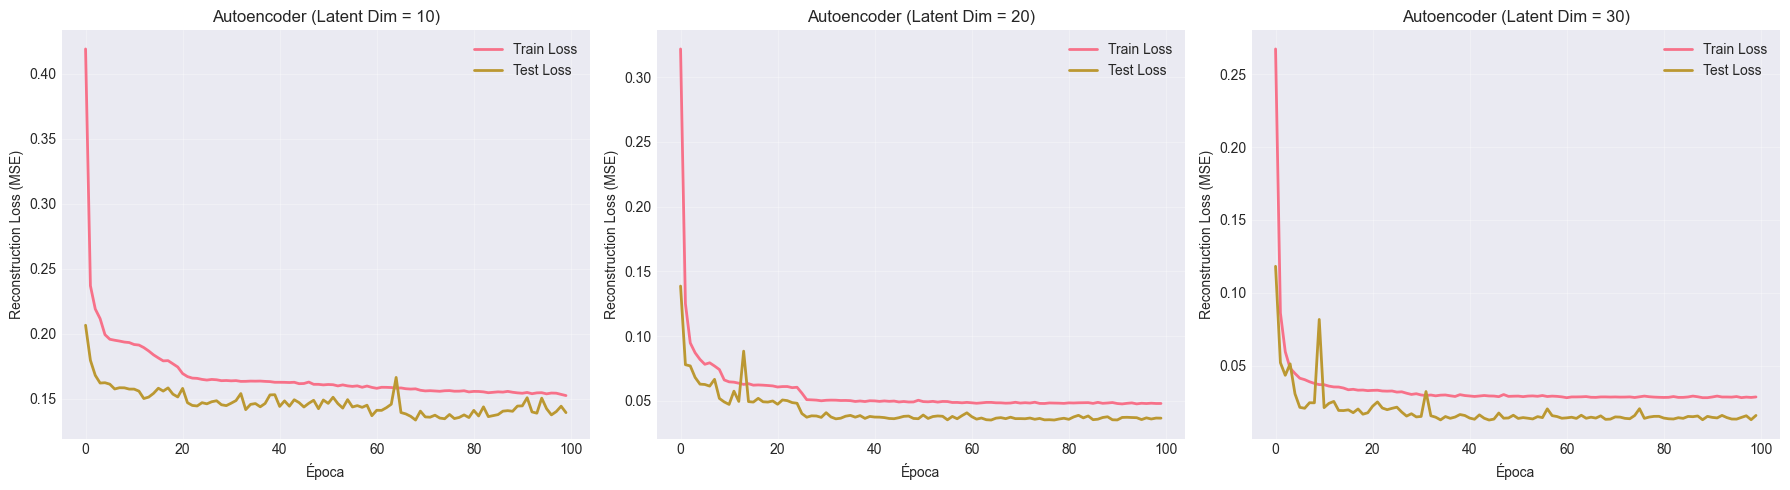

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, latent_size in enumerate(latent_sizes):
    axes[idx].plot(ae_losses[latent_size]['train'], label='Train Loss', linewidth=2)
    axes[idx].plot(ae_losses[latent_size]['test'], label='Test Loss', linewidth=2)
    axes[idx].set_xlabel('Época')
    axes[idx].set_ylabel('Reconstruction Loss (MSE)')
    axes[idx].set_title(f'Autoencoder (Latent Dim = {latent_size})')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/autoencoder_learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Extracción de Representaciones Latentes

In [8]:
def extract_latent_features(autoencoder, data, device='cpu'):
    """
    Extrae las representaciones latentes del autoencoder.
    """
    autoencoder.eval()
    with torch.no_grad():
        data_tensor = torch.FloatTensor(data).to(device)
        latent = autoencoder.encode(data_tensor)
        return latent.cpu().numpy()

latent_features = {}

for latent_size in latent_sizes:
    ae = autoencoders[latent_size]
    
    X_train_latent = extract_latent_features(ae, X_train_scaled, device)
    X_test_latent = extract_latent_features(ae, X_test_scaled, device)
    
    latent_features[latent_size] = {
        'train': X_train_latent,
        'test': X_test_latent
    }
    
    print(f"Latent size {latent_size}: Train shape = {X_train_latent.shape}, Test shape = {X_test_latent.shape}")

Latent size 10: Train shape = (67229, 10), Test shape = (22203, 10)
Latent size 20: Train shape = (67229, 20), Test shape = (22203, 20)
Latent size 30: Train shape = (67229, 30), Test shape = (22203, 30)


## 8. Regresión Lineal sobre Espacio Latente

In [9]:
def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{'='*50}")
    print(f"Resultados para: {model_name}")
    print(f"{'='*50}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R2:   {r2:.4f}")
    
    return {
        'model': model_name,
        'rmse': rmse,
        'mae': mae,
        'r2': r2
    }

ae_lr_results = {}

for latent_size in latent_sizes:
    print(f"\nEntrenando Regresión Lineal sobre espacio latente (dim={latent_size})...")
    
    X_train_latent = latent_features[latent_size]['train']
    X_test_latent = latent_features[latent_size]['test']
    
    lr = LinearRegression()
    lr.fit(X_train_latent, y_train)
    
    y_pred = lr.predict(X_test_latent)
    
    results = evaluate_model(y_test, y_pred, f"AE-LR (Latent={latent_size})")
    ae_lr_results[latent_size] = results


Entrenando Regresión Lineal sobre espacio latente (dim=10)...

Resultados para: AE-LR (Latent=10)
RMSE: 3153.4033
MAE:  2051.8012
R2:   -1.3340

Entrenando Regresión Lineal sobre espacio latente (dim=20)...

Resultados para: AE-LR (Latent=20)
RMSE: 3302.9086
MAE:  1834.9874
R2:   -1.5606

Entrenando Regresión Lineal sobre espacio latente (dim=30)...

Resultados para: AE-LR (Latent=30)
RMSE: 3760.5096
MAE:  2357.7392
R2:   -2.3193


## 9. Visualización en 2D del Espacio Latente

Entrenamos un autoencoder con dimensión latente = 2 para visualización

In [10]:
print("Entrenando Autoencoder con dimensión latente = 2 para visualización...\n")

ae_2d = Autoencoder(input_size, latent_size=2)
criterion = nn.MSELoss()
optimizer = optim.Adam(ae_2d.parameters(), lr=0.001, weight_decay=1e-5)

train_losses_2d, test_losses_2d = train_autoencoder(
    ae_2d, train_loader, test_loader, criterion, optimizer, num_epochs=100, device=device
)

X_train_latent_2d = extract_latent_features(ae_2d, X_train_scaled, device)
X_test_latent_2d = extract_latent_features(ae_2d, X_test_scaled, device)

print(f"Shape del espacio latente 2D: {X_train_latent_2d.shape}")

Entrenando Autoencoder con dimensión latente = 2 para visualización...

Epoch [20/100], Train Loss: 0.451606, Test Loss: 0.484479
Epoch [40/100], Train Loss: 0.448064, Test Loss: 0.470580
Epoch [60/100], Train Loss: 0.443328, Test Loss: 3.082217
Epoch [80/100], Train Loss: 0.442254, Test Loss: 3.741730
Epoch [100/100], Train Loss: 0.441544, Test Loss: 3.395452
Shape del espacio latente 2D: (67229, 2)


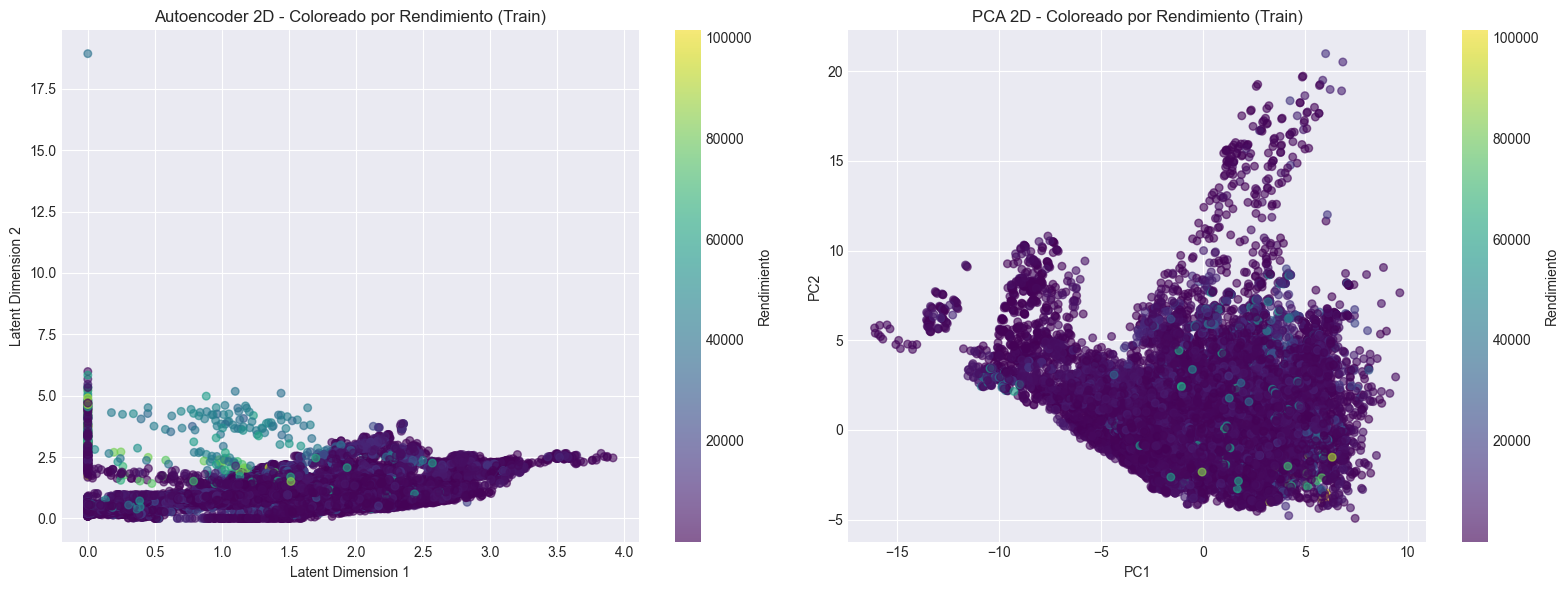

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = axes[0].scatter(X_train_latent_2d[:, 0], X_train_latent_2d[:, 1], 
                           c=y_train, cmap='viridis', alpha=0.6, s=30)
axes[0].set_xlabel('Latent Dimension 1')
axes[0].set_ylabel('Latent Dimension 2')
axes[0].set_title('Autoencoder 2D - Coloreado por Rendimiento (Train)')
plt.colorbar(scatter1, ax=axes[0], label='Rendimiento')

X_train_pca_2d = np.load('../data/processed/X_train_pca.npy')[:, :2]
scatter2 = axes[1].scatter(X_train_pca_2d[:, 0], X_train_pca_2d[:, 1], 
                           c=y_train, cmap='viridis', alpha=0.6, s=30)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('PCA 2D - Coloreado por Rendimiento (Train)')
plt.colorbar(scatter2, ax=axes[1], label='Rendimiento')

plt.tight_layout()
plt.savefig('../figures/autoencoder_vs_pca_2d.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Regresión Lineal sobre Autoencoder 2D

In [12]:
print("Entrenando Regresión Lineal sobre espacio latente 2D...")

lr_ae_2d = LinearRegression()
lr_ae_2d.fit(X_train_latent_2d, y_train)

y_pred_ae_2d = lr_ae_2d.predict(X_test_latent_2d)

results_ae_lr_2d = evaluate_model(y_test, y_pred_ae_2d, "AE-LR (Latent=2)")

Entrenando Regresión Lineal sobre espacio latente 2D...

Resultados para: AE-LR (Latent=2)
RMSE: 3091.7804
MAE:  2219.7738
R2:   -1.2437


## 11. Comparación Completa: Autoencoder vs PCA vs Otros Modelos

In [13]:
with open('../results/linear_regression_results.pkl', 'rb') as f:
    lr_results = pickle.load(f)

with open('../results/xgboost_results.pkl', 'rb') as f:
    xgb_results = pickle.load(f)

comparison_df = pd.DataFrame([
    lr_results['lr_x_val'],
    lr_results['lr_z_val'],
    ae_lr_results[10],
    ae_lr_results[20],
    ae_lr_results[30],
    results_ae_lr_2d
])

print("\n" + "="*70)
print("COMPARACIÓN: PCA vs AUTOENCODER (Regresión Lineal)")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)


COMPARACIÓN: PCA vs AUTOENCODER (Regresión Lineal)
                                 model        rmse         mae        r2
    Linear Regression (X) - Validation 3186.590903 1822.042463  0.095716
Linear Regression (Z-PCA) - Validation 3128.231027 1785.745667  0.128535
                     AE-LR (Latent=10) 3153.403259 2051.801157 -1.334049
                     AE-LR (Latent=20) 3302.908646 1834.987393 -1.560614
                     AE-LR (Latent=30) 3760.509626 2357.739245 -2.319284
                      AE-LR (Latent=2) 3091.780442 2219.773834 -1.243718


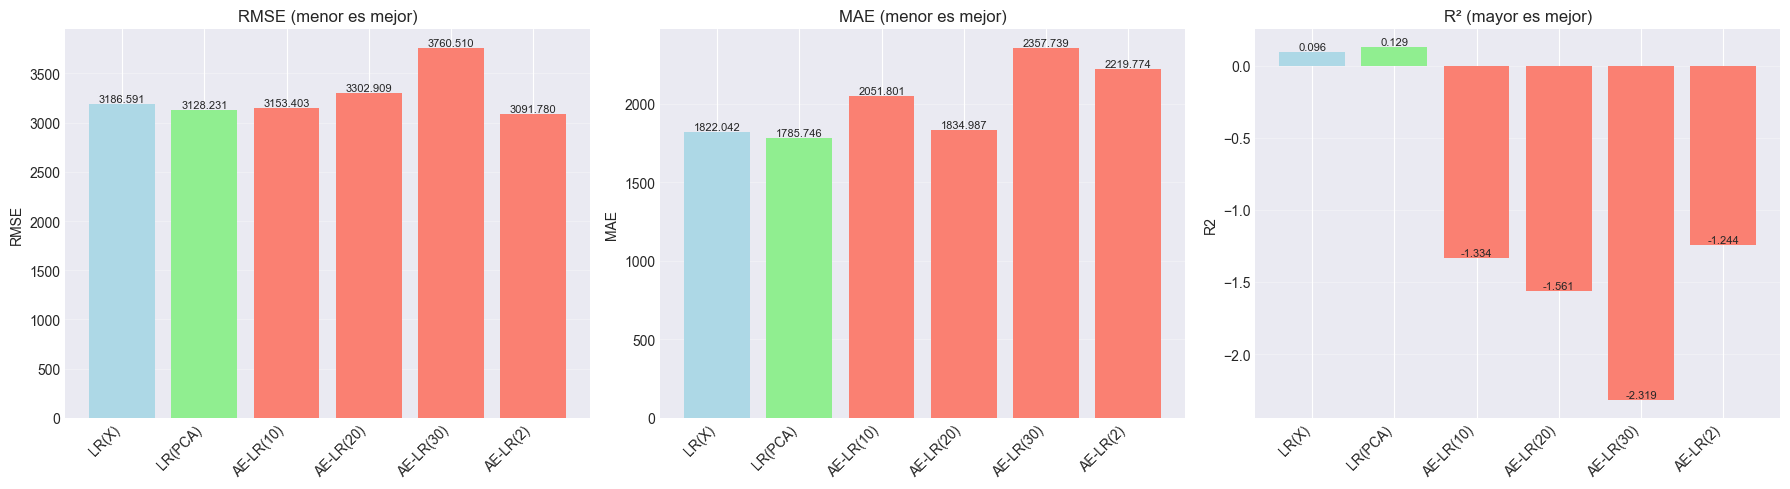

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['rmse', 'mae', 'r2']
titles = ['RMSE (menor es mejor)', 'MAE (menor es mejor)', 'R² (mayor es mejor)']
model_labels = ['LR(X)', 'LR(PCA)', 'AE-LR(10)', 'AE-LR(20)', 'AE-LR(30)', 'AE-LR(2)']

colors = ['lightblue', 'lightgreen'] + ['salmon']*4

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    values = comparison_df[metric].values
    
    axes[idx].bar(range(len(values)), values, color=colors)
    axes[idx].set_xticks(range(len(values)))
    axes[idx].set_xticklabels(model_labels, rotation=45, ha='right')
    axes[idx].set_ylabel(metric.upper())
    axes[idx].set_title(title)
    axes[idx].grid(True, alpha=0.3, axis='y')
    
    for i, v in enumerate(values):
        axes[idx].text(i, v, f'{v:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('../figures/autoencoder_vs_pca_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 12. Análisis de Reconstrucción del Autoencoder

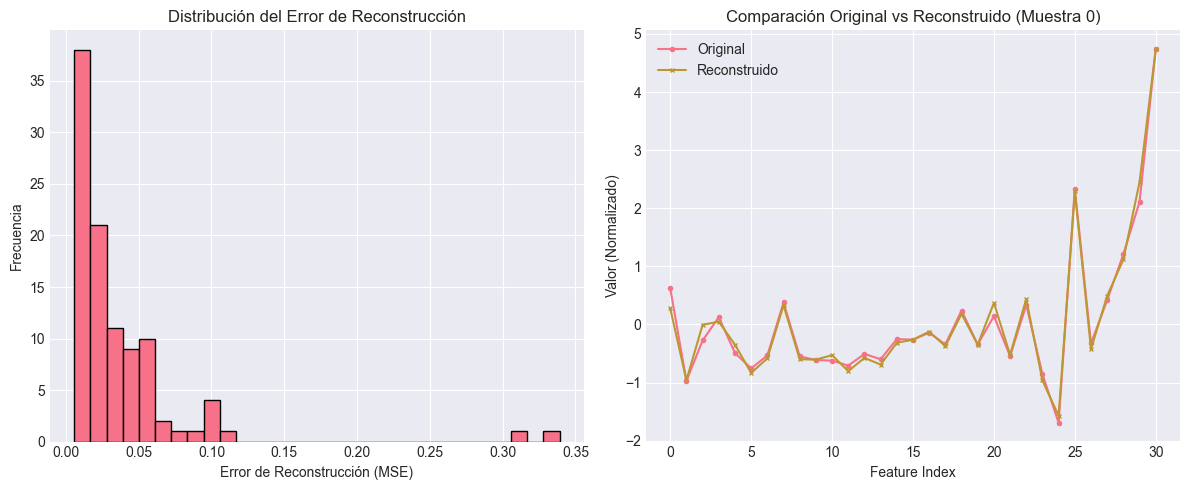

Error de reconstrucción promedio: 0.036615
Error de reconstrucción std: 0.047177


In [15]:
ae_best = autoencoders[20]
ae_best.eval()

with torch.no_grad():
    X_test_tensor = torch.FloatTensor(X_test_scaled[:100]).to(device)
    X_reconstructed = ae_best(X_test_tensor).cpu().numpy()

reconstruction_error = np.mean((X_test_scaled[:100] - X_reconstructed)**2, axis=1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(reconstruction_error, bins=30, edgecolor='black')
plt.xlabel('Error de Reconstrucción (MSE)')
plt.ylabel('Frecuencia')
plt.title('Distribución del Error de Reconstrucción')

plt.subplot(1, 2, 2)
sample_idx = 0
plt.plot(X_test_scaled[sample_idx], label='Original', marker='o', markersize=3)
plt.plot(X_reconstructed[sample_idx], label='Reconstruido', marker='x', markersize=3)
plt.xlabel('Feature Index')
plt.ylabel('Valor (Normalizado)')
plt.title(f'Comparación Original vs Reconstruido (Muestra {sample_idx})')
plt.legend()

plt.tight_layout()
plt.savefig('../figures/autoencoder_reconstruction.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Error de reconstrucción promedio: {reconstruction_error.mean():.6f}")
print(f"Error de reconstrucción std: {reconstruction_error.std():.6f}")

## 13. Comparación Final con TODOS los Modelos

In [16]:
with open('../results/feature_engineering_results.pkl', 'rb') as f:
    fe_results = pickle.load(f)

with open('../results/neural_network_results.pkl', 'rb') as f:
    nn_results = pickle.load(f)

final_comparison = pd.DataFrame([
    lr_results['lr_x_val'],
    lr_results['lr_z_val'],
    xgb_results['xgb_x_test'],
    xgb_results['xgb_z_test'],
    fe_results['lr_x_eng'],
    fe_results['xgb_x_eng'],
    nn_results['nn_2layers'],
    nn_results['nn_2layers_eng'],
    ae_lr_results[20]
])

print("\n" + "="*80)
print("COMPARACIÓN FINAL DE TODOS LOS MODELOS")
print("="*80)
print(final_comparison.to_string(index=False))
print("="*80)

print("\nMEJOR MODELO POR MÉTRICA:")
print(f"Mejor R²:   {final_comparison.loc[final_comparison['r2'].idxmax(), 'model']} = {final_comparison['r2'].max():.4f}")
print(f"Mejor RMSE: {final_comparison.loc[final_comparison['rmse'].idxmin(), 'model']} = {final_comparison['rmse'].min():.4f}")
print(f"Mejor MAE:  {final_comparison.loc[final_comparison['mae'].idxmin(), 'model']} = {final_comparison['mae'].min():.4f}")


COMPARACIÓN FINAL DE TODOS LOS MODELOS
                                 model        rmse         mae        r2
    Linear Regression (X) - Validation 3186.590903 1822.042463  0.095716
Linear Regression (Z-PCA) - Validation 3128.231027 1785.745667  0.128535
              XGBoost (X) - Validation 1179.553865  590.828236  0.876095
          XGBoost (Z-PCA) - Validation 2801.135385 1675.557816  0.301252
                           LR (X + FE) 3130.835632 1792.921431 -1.300761
                          XGB (X + FE) 1053.919369  609.628511  0.739285
                           NN 2-Layers 1549.963790 1032.926392  0.436110
                      NN 2-Layers + FE 1593.059321 1086.150757  0.404317
                     AE-LR (Latent=20) 3302.908646 1834.987393 -1.560614

MEJOR MODELO POR MÉTRICA:
Mejor R²:   XGBoost (X) - Validation = 0.8761
Mejor RMSE: XGB (X + FE) = 1053.9194
Mejor MAE:  XGBoost (X) - Validation = 590.8282


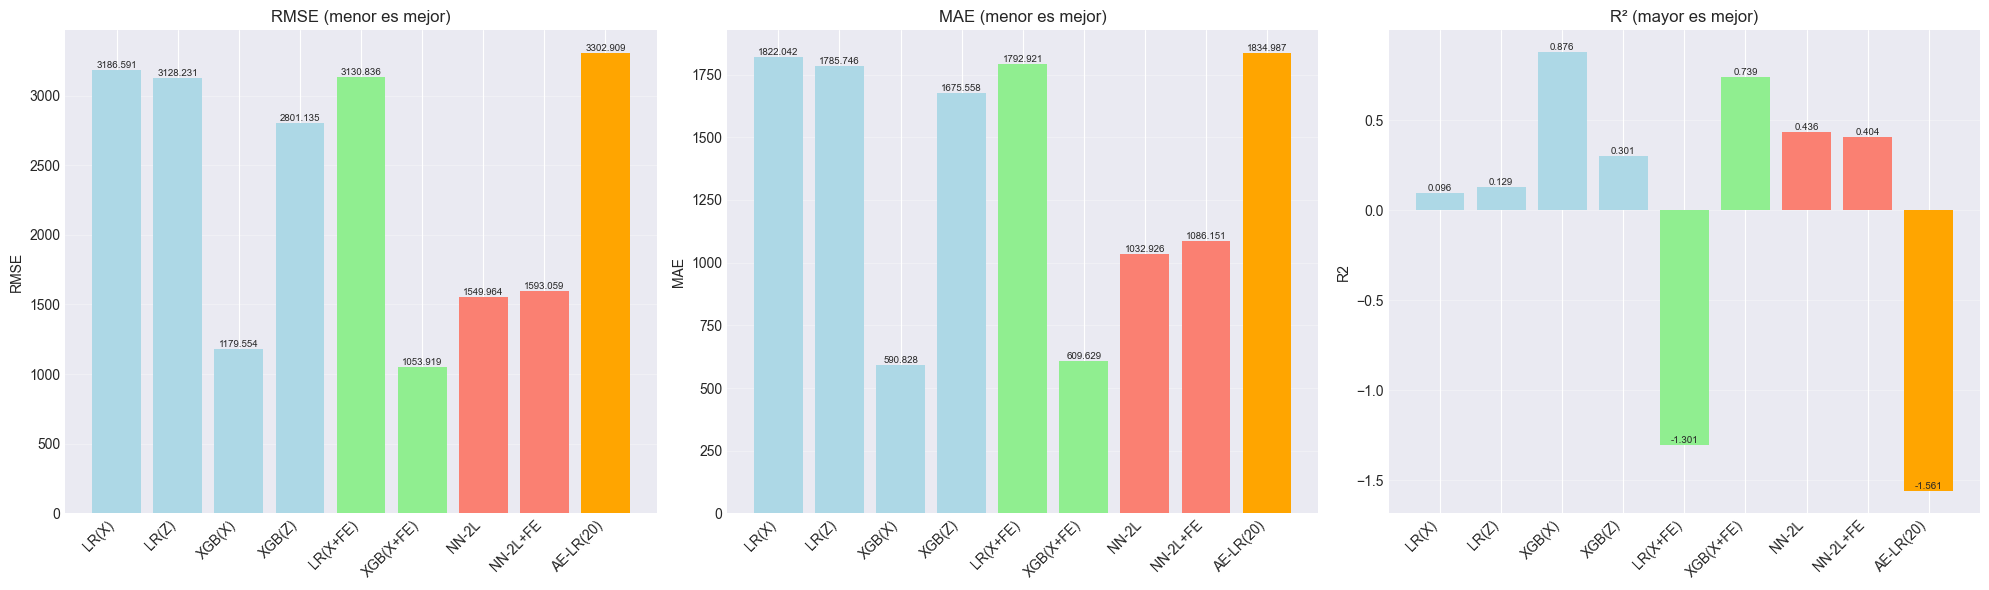

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

metrics = ['rmse', 'mae', 'r2']
titles = ['RMSE (menor es mejor)', 'MAE (menor es mejor)', 'R² (mayor es mejor)']
model_labels = ['LR(X)', 'LR(Z)', 'XGB(X)', 'XGB(Z)', 
                'LR(X+FE)', 'XGB(X+FE)', 
                'NN-2L', 'NN-2L+FE', 'AE-LR(20)']

colors = ['lightblue']*4 + ['lightgreen']*2 + ['salmon']*2 + ['orange']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    values = final_comparison[metric].values
    
    axes[idx].bar(range(len(values)), values, color=colors)
    axes[idx].set_xticks(range(len(values)))
    axes[idx].set_xticklabels(model_labels, rotation=45, ha='right')
    axes[idx].set_ylabel(metric.upper())
    axes[idx].set_title(title)
    axes[idx].grid(True, alpha=0.3, axis='y')
    
    for i, v in enumerate(values):
        axes[idx].text(i, v, f'{v:.3f}', ha='center', va='bottom', fontsize=7, rotation=0)

plt.tight_layout()
plt.savefig('../figures/final_complete_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 14. Guardar Modelos y Resultados

In [18]:
for latent_size, ae in autoencoders.items():
    torch.save(ae.state_dict(), f'../models/autoencoder_latent_{latent_size}.pth')

torch.save(ae_2d.state_dict(), '../models/autoencoder_latent_2.pth')

print("Autoencoders guardados.")

Autoencoders guardados.


In [19]:
ae_results_summary = {
    'ae_lr_results': ae_lr_results,
    'ae_lr_2d': results_ae_lr_2d,
    'ae_losses': ae_losses,
    'train_losses_2d': train_losses_2d,
    'test_losses_2d': test_losses_2d
}

with open('../results/autoencoder_results.pkl', 'wb') as f:
    pickle.dump(ae_results_summary, f)

print("Resultados de autoencoders guardados.")

Resultados de autoencoders guardados.


In [20]:
final_comparison.to_csv('../results/final_models_comparison.csv', index=False)
print("Comparación final guardada en CSV.")

Comparación final guardada en CSV.
